In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from ASM_utils import AdaptiveSmoothing
from matplotlib.colors import LinearSegmentedColormap
import warnings 
import os
import random
warnings.filterwarnings("ignore")
device = torch.device("cpu")
lane = 1
rds = np.load(f'../data/processed_data/rds/lane{lane}/2024-07-09.npy')
speed = np.load(f'../data/processed_data/rds/lane{lane}/2024-07-09.npy')
motion = np.load(f'../data/processed_data/motion/lane{lane}/2024-07-09.npy')
space_size, time_size = speed.shape
speed = torch.tensor(speed, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
best_model_path = f'../logs/calibration/20250607_203336/best_model_lane{lane}.pt'

dx = 0.02                  # distance per cell
dt = 4.0                    # time per cell
kernel_time_window = time_size * dt  # seconds
kernel_space_window = space_size * dx  # same units as dx
# load the best model
best_model_path = f'../model/20250607_221107/best_model_lane{lane}.pt'
calibrated_model = torch.load(best_model_path, map_location=device)
calibrated = AdaptiveSmoothing(kernel_time_window,
                          kernel_space_window,
                          dx, dt,
                          init_tau=calibrated_model['tau'],
                          init_delta=calibrated_model['delta'],
                          init_c_cong=calibrated_model['c_cong'],
                          init_c_free=calibrated_model['c_free'],
                          init_v_delta=calibrated_model['v_delta'],
                          init_v_thr=calibrated_model['v_thr']
                          ).to(device)

calibrated.eval()
original = AdaptiveSmoothing(kernel_time_window,
                          kernel_space_window,
                          dx, dt,
                          init_tau=15.00,
                          init_delta=0.15,
                          init_c_cong=9.30,
                          init_c_free=-43.50,
                          init_v_delta=12.40,
                          init_v_thr=37.30).to(device)
original.eval()

AdaptiveSmoothing()

In [2]:
with torch.no_grad():
    smoothed = calibrated(speed)
    calibrated_asm_speed = smoothed.cpu().numpy().squeeze()
with torch.no_grad():
    original_asm = original(speed)
    original_asm_speed = original_asm.cpu().numpy().squeeze()

In [9]:
# get the countor of a matrix 
import torch
import numpy as np
import matplotlib.pyplot as plt
def get_contour(matrix, threshold=30.0):
    """
    Get the contour of a matrix based on a threshold.
    
    Args:
        matrix (np.ndarray): The input matrix.
        threshold (float): The threshold value to determine the contour.
        
    Returns:
        np.ndarray: A binary matrix representing the contour.
    """
    binary_matrix = (matrix <= threshold).astype(int)
    return binary_matrix

# caculate the IoU of two contours for two matrices
def calculate_iou(matrix1, matrix2, threshold=30.0):
    """
    Calculate the Intersection over Union (IoU) of two matrices,
    plus counts of elements unique to each.
    
    Args:
        matrix1 (np.ndarray): The first binary matrix.
        matrix2 (np.ndarray): The second binary matrix.
        
    Returns:
        tuple: (iou, only_in_1, only_in_2)
    """
    contour1 = get_contour(matrix1, threshold)
    contour2 = get_contour(matrix2, threshold)

    intersection = np.logical_and(contour1, contour2).sum()
    union = np.logical_or(contour1, contour2).sum()

    # return the intersection matrix as well
    intersection_matrix = np.logical_and(contour1, contour2).astype(int)
    only_in_1_matrix = np.logical_and(contour1, np.logical_not(contour2)).astype(int)
    only_in_2_matrix = np.logical_and(contour2, np.logical_not(contour1)).astype(int)
    iou = intersection / union if union != 0 else 0.0
    only1 = only_in_1_matrix.sum()/union if union != 0 else 0.0
    only2 = only_in_2_matrix.sum()/union if union != 0 else 0.0
    iou = round(iou, 4)
    only1 = round(only1, 4)
    only2 = round(only2, 4)
    return iou, only1, only2, intersection_matrix, only_in_1_matrix, only_in_2_matrix

In [10]:
results = []
for threshold in [5, 10, 15, 20, 25, 30]:
    iou, only1, only2, _, _, _ = calculate_iou(original_asm_speed, motion, threshold=threshold)
    results.append({'Threshold': threshold, 'IoU': iou, 'Only in ASM': only1, 'Only in GT': only2})

df_results = pd.DataFrame(results)
print(df_results)

# Output as LaTeX table
latex_table = df_results.to_latex(index=False, float_format="%.4f")
print(latex_table)

   Threshold     IoU  Only in ASM  Only in GT
0          5  0.0000       0.0000      1.0000
1         10  0.0850       0.0096      0.9055
2         15  0.4167       0.0638      0.5195
3         20  0.6561       0.0857      0.2583
4         25  0.7541       0.0869      0.1589
5         30  0.7859       0.1012      0.1130
\begin{tabular}{rrrr}
\toprule
Threshold & IoU & Only in ASM & Only in GT \\
\midrule
5 & 0.0000 & 0.0000 & 1.0000 \\
10 & 0.0850 & 0.0096 & 0.9055 \\
15 & 0.4167 & 0.0638 & 0.5195 \\
20 & 0.6561 & 0.0857 & 0.2583 \\
25 & 0.7541 & 0.0869 & 0.1589 \\
30 & 0.7859 & 0.1012 & 0.1130 \\
\bottomrule
\end{tabular}



In [11]:
results = []
for threshold in [5, 10, 15, 20, 25, 30]:
    iou_o, only1_o, only2_o, _, _, _ = calculate_iou(original_asm_speed, motion, threshold=threshold)
    iou_c, only1_c, only2_c, _, _, _ = calculate_iou(calibrated_asm_speed, motion, threshold=threshold)
    results.append({'Threshold': threshold, 'IoU_O': iou_o, 'IoU_C': iou_c,
                    'Only in ASM_O': only1_o, 'Only in ASM_C': only1_c,
                    'Only in GT_O': only2_o, 'Only in GT_C': only2_c})

df_results = pd.DataFrame(results)
print(df_results)

# Output as LaTeX table
latex_table = df_results.to_latex(index=False, float_format="%.4f")
print(latex_table)

   Threshold   IoU_O   IoU_C  Only in ASM_O  Only in ASM_C  Only in GT_O  \
0          5  0.0000  0.0071         0.0000         0.0007        1.0000   
1         10  0.0850  0.2011         0.0096         0.0442        0.9055   
2         15  0.4167  0.5279         0.0638         0.1043        0.5195   
3         20  0.6561  0.6869         0.0857         0.1100        0.2583   
4         25  0.7541  0.7649         0.0869         0.0997        0.1589   
5         30  0.7859  0.7877         0.1012         0.1042        0.1130   

   Only in GT_C  
0        0.9922  
1        0.7547  
2        0.3678  
3        0.2031  
4        0.1354  
5        0.1081  
\begin{tabular}{rrrrrrr}
\toprule
Threshold & IoU_O & IoU_C & Only in ASM_O & Only in ASM_C & Only in GT_O & Only in GT_C \\
\midrule
5 & 0.0000 & 0.0071 & 0.0000 & 0.0007 & 1.0000 & 0.9922 \\
10 & 0.0850 & 0.2011 & 0.0096 & 0.0442 & 0.9055 & 0.7547 \\
15 & 0.4167 & 0.5279 & 0.0638 & 0.1043 & 0.5195 & 0.3678 \\
20 & 0.6561 & 0.6869 & 0.085

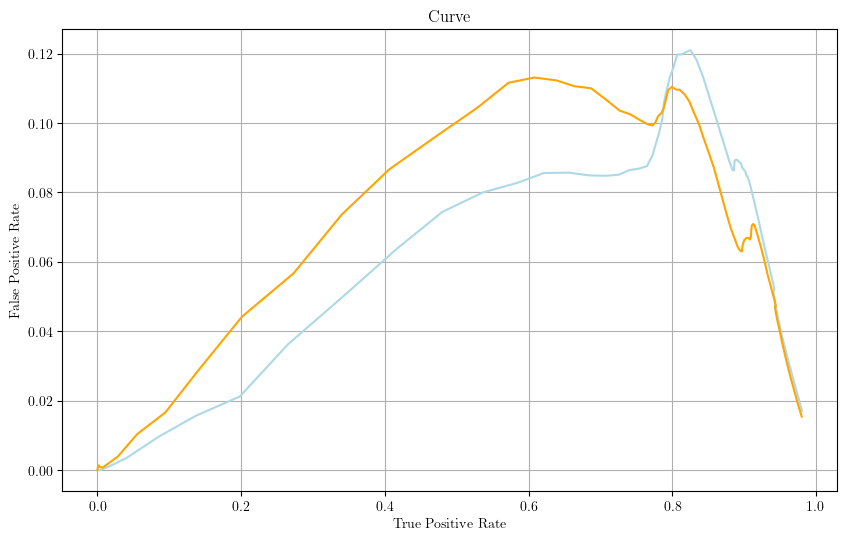

In [19]:
results = []
for threshold in range(0, 81, 1):
    iou_o, only1_o, only2_o, _, _, _ = calculate_iou(original_asm_speed, motion, threshold=threshold)
    iou_c, only1_c, only2_c, _, _, _ = calculate_iou(calibrated_asm_speed, motion, threshold=threshold)
    results.append({'Threshold': threshold, 'IoU_O': iou_o, 'IoU_C': iou_c,
                    'Only in ASM_O': only1_o, 'Only in ASM_C': only1_c,
                    'Only in GT_O': only2_o, 'Only in GT_C': only2_c})

df_results = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
# tex font
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
# ROC curve
plt.plot(df_results['IoU_O'], df_results['Only in ASM_O'], color = 'lightblue')
plt.plot(df_results['IoU_C'], df_results['Only in ASM_C'],color='orange')
plt.title('Curve')
plt.xlabel('True Positive Rate')
plt.ylabel('False Positive Rate')
plt.grid()

In [9]:
print(f"Only in smoothed: {only1}")
print(f"Only in motion: {only2}")
print(f"iou: {iou}")

Only in smoothed: 0.1016
Only in motion: 0.1113
iou: 0.7871


IoU: 0.7871


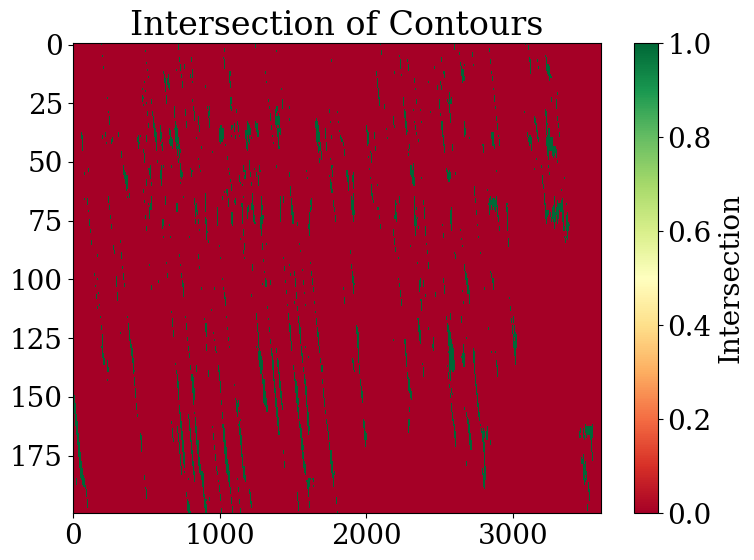

In [10]:
iou, only1, only2, intersection_matrix, only_in_1_matrix, only_in_2_matrix = calculate_iou(sm, motion)
print(f"IoU: {iou}")
plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 20, 'font.family': 'serif'})
plt.imshow(only_in_motion, cmap='RdYlGn', interpolation='nearest', origin='lower', vmin=0, vmax=1, aspect='auto')
plt.colorbar(label='Intersection')
plt.title('Intersection of Contours')
plt.tight_layout()
# reverse the y-axis
plt.gca().invert_yaxis()

IoU: 0.7871


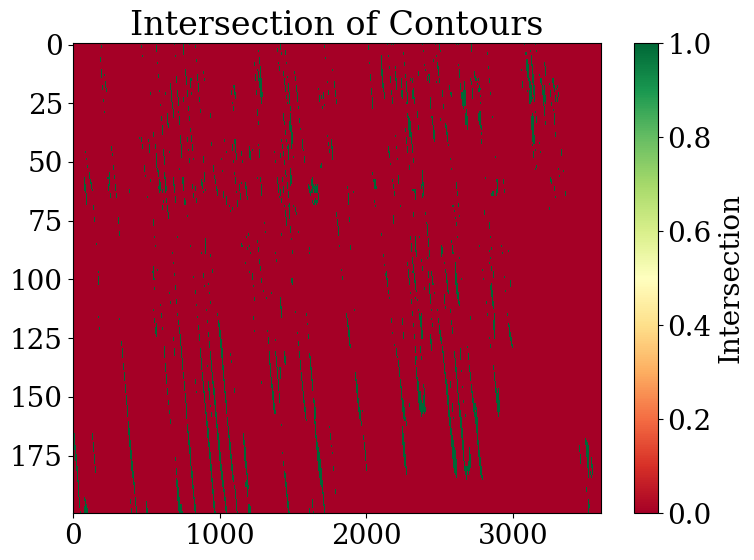

In [11]:
iou, only1, only2, intersection_matrix, only_in_1_matrix, only_in_2_matrix = calculate_iou(sm, motion)
print(f"IoU: {iou}")
plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 20, 'font.family': 'serif'})
plt.imshow(only_in_sm, cmap='RdYlGn', interpolation='nearest', origin='lower', vmin=0, vmax=1, aspect='auto')
plt.colorbar(label='Intersection')
plt.title('Intersection of Contours')
plt.tight_layout()
# reverse the y-axis
plt.gca().invert_yaxis()

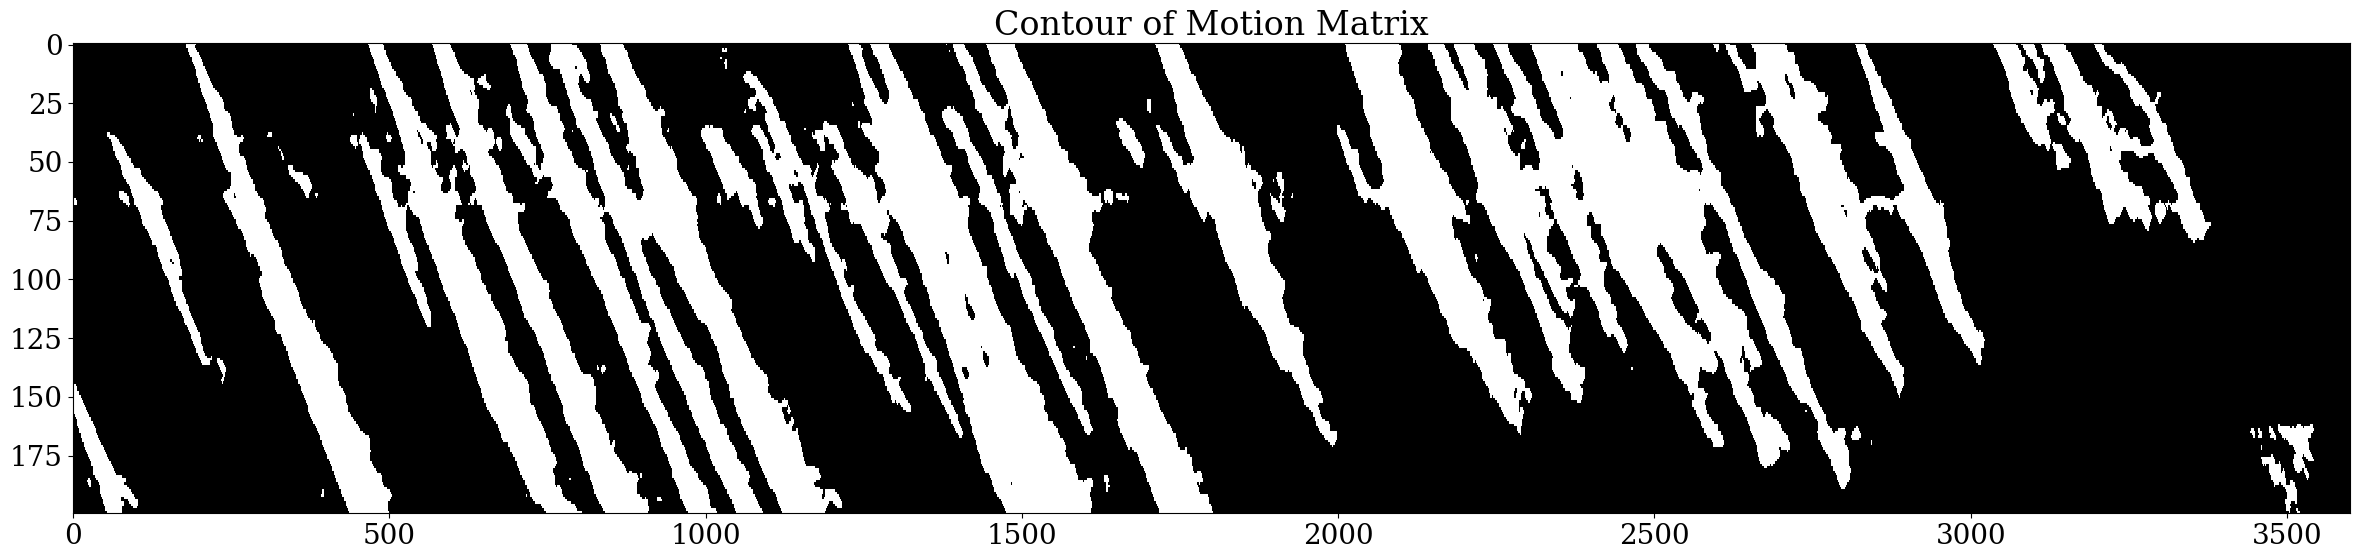

In [12]:
# visualize the contour of the matrix of motion
motion_contour = get_contour(motion,30)
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 20, 'font.family': 'serif'})
plt.imshow(motion_contour, cmap='gray', interpolation='nearest', origin='lower', aspect='auto')
plt.title('Contour of Motion Matrix')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

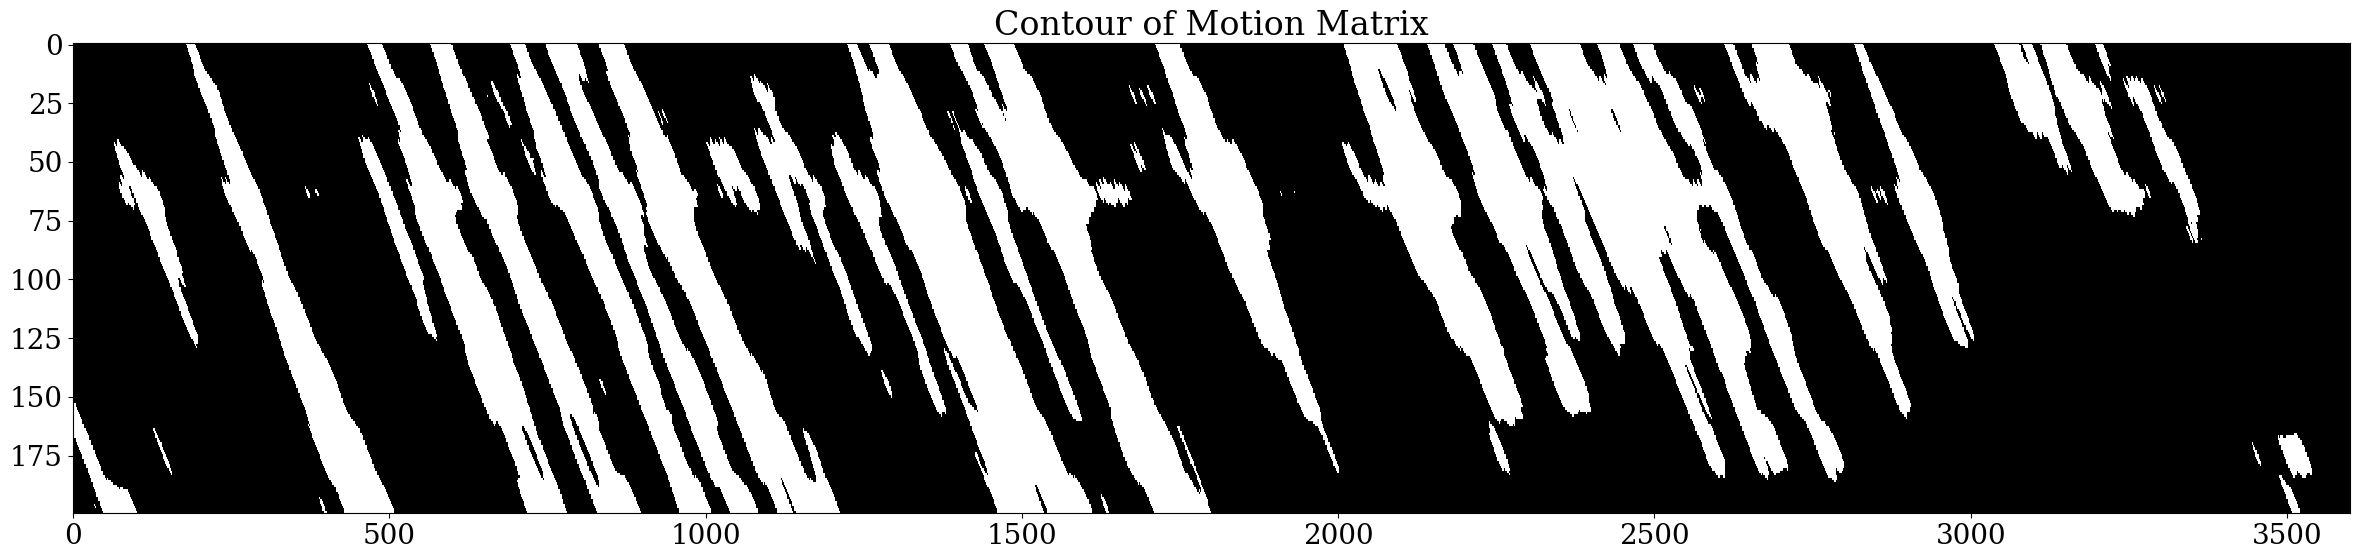

In [13]:
# visualize the contour of the matrix of motion
motion_contour = get_contour(sm,30)
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 20, 'font.family': 'serif'})
plt.imshow(motion_contour, cmap='gray', interpolation='nearest', origin='lower', aspect='auto')
plt.title('Contour of Motion Matrix')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()